## Calculating the Return of Indices

Consider three famous American market indices – Dow Jones, S&P 500, and the Nasdaq for the period of 1st of January 2000 until today.

In [1]:
import datetime

import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf

symbols = {
    "Dow Jones": "^DJI",
    "S&P 500": "^GSPC",
    "Nasdaq": "^IXIC",
}
start_date = "2000-01-01"
end_date = datetime.date.today().isoformat()

raw = yf.download(list(symbols.values()), start=start_date, end=end_date, progress=False)
if raw.empty:
    raise RuntimeError(
        "No data was downloaded from Yahoo Finance. "
        "Please check your internet connection and try again."
    )
close = raw["Close"].copy()
close.columns = list(symbols.keys())
close = close.sort_index()
close.head()

,Dow Jones,S&P 500,Nasdaq
Date,,,
2000-01-03,11357.509766,1455.219971,4131.149902
2000-01-04,10997.929688,1399.420044,3901.689941
2000-01-05,11122.650391,1402.109985,3877.540039
2000-01-06,11253.259766,1403.449951,3727.129883
2000-01-07,11522.559570,1441.469971,3882.620117


Normalize the data to 100 and plot the results on a graph. 

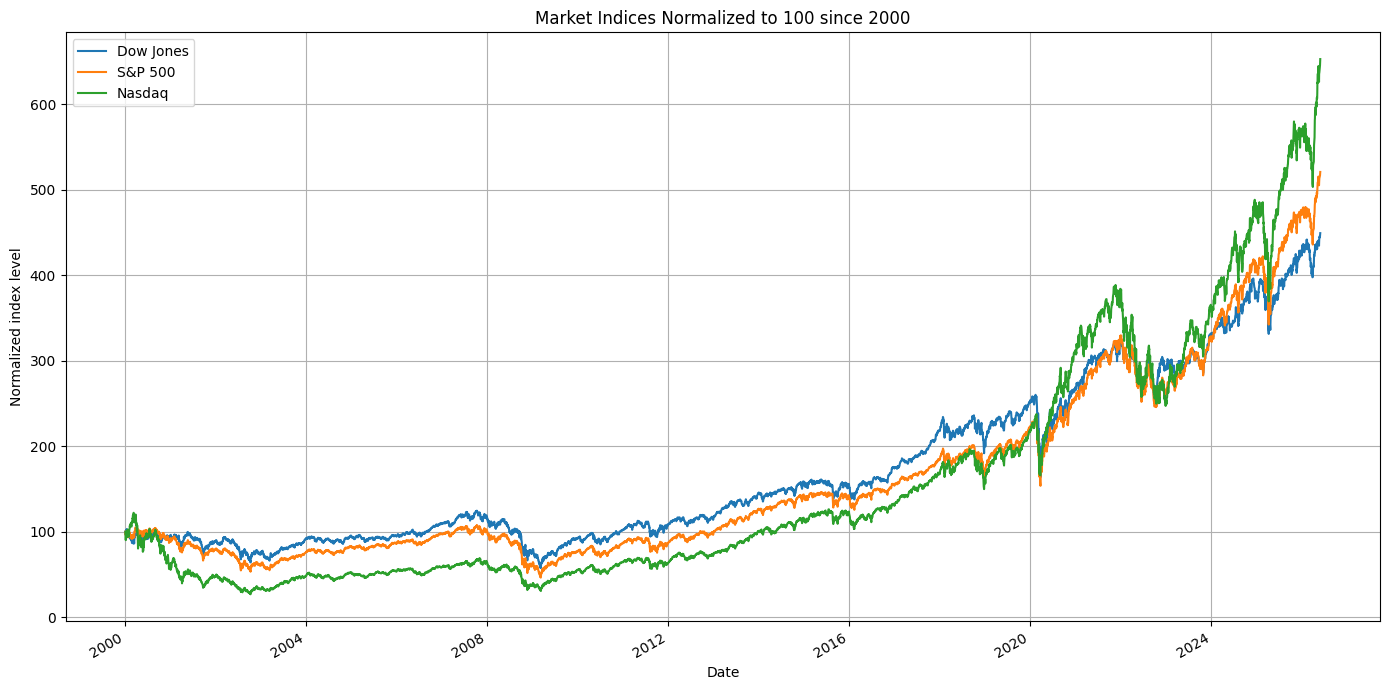

In [2]:
normalized = close / close.iloc[0] * 100
ax = normalized.plot(figsize=(14, 7), title="Market Indices Normalized to 100 since 2000")
ax.set_xlabel("Date")
ax.set_ylabel("Normalized index level")
ax.grid(True)
plt.tight_layout()
plt.show()

How would you explain the common and the different parts of the behavior of the three indices?

The three indices share common trends driven by the same macroeconomic and market cycles, such as the 2000 tech bubble, the 2008 financial crisis, and the COVID-19 selloff. They differ in sector composition and volatility: Nasdaq is more technology-heavy and therefore more volatile, S&P 500 is broader and smoother, while Dow Jones is price-weighted and can be influenced more heavily by a few large companies.

*****

Obtain the simple returns of the indices.

In [3]:
simple_returns = close.pct_change().dropna()
simple_returns.head()

,Dow Jones,S&P 500,Nasdaq
Date,,,
2000-01-04,-0.031660,-0.038345,-0.055544
2000-01-05,0.011340,0.001922,-0.006190
2000-01-06,0.011743,0.000956,-0.038790
2000-01-07,0.023931,0.027090,0.041718
2000-01-10,0.004308,0.011190,0.043025


Estimate the average annual return of each index.

In [ ]:
trading_days = 252
annualized_arithmetic = simple_returns.mean() * trading_days
cagr = (close.iloc[-1] / close.iloc[0]) ** (trading_days / simple_returns.shape[0]) - 1
annual_returns = pd.DataFrame({
    "Annualized mean simple return": annualized_arithmetic,
    "CAGR": cagr,
})
annual_returns = annual_returns.rename_axis("Index")
annual_returns = annual_returns.multiply(100).round(2)
annual_returns.columns = [f"{col} (%)" for col in annual_returns.columns]
annual_returns

AttributeError: The '.style' accessor requires jinja2